In [59]:
# DIKRA ARDAHI

In [60]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


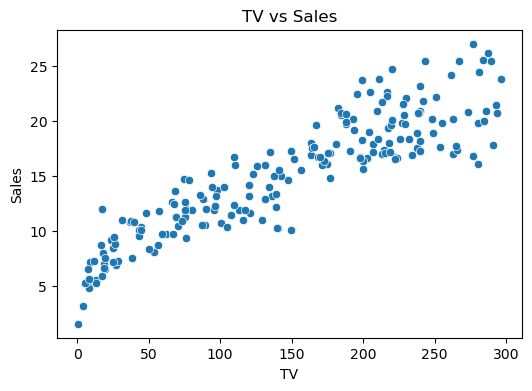

In [61]:
# Charger le dataset
df = pd.read_csv("advertising.csv")


# Exploration des données
print(df.head())
print(df.info())

# Visualisation simple de la relation entre la colonne TV et les ventes (Sales)
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV vs Sales")
plt.show()

In [62]:
# Définition des variables pour la régression

# Linéaire simple
X_simple = df[['TV']].values
# Linéaire multiple
X_multi = df.drop(columns = ["Sales"])
# variable cible
y = df['Sales']

In [63]:
# Séparation des données pour entraînement et testt
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)


In [64]:
# Regression linéaire  "from scratch"
X_b = np.c_[np.ones((X_train_s.shape[0],1)), X_train_s]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train_s)
print("Paramètres linéaire (from scratch) :", theta)

# Prédiction des valeurs y
X_test_b = np.c_[np.ones((X_test_s.shape[0],1)), X_test_s]
y_pred_s_linear = X_test_b.dot(theta)

# Evaluation du modèle from scratch
print("MSE:", np.mean((y_test_s - y_pred_s_linear) ** 2))
print("R²:", 1 - (np.sum((y_test_s - y_pred_s_linear) ** 2) / np.sum((y_test_s - np.mean(y_test_s)) ** 2)))


Paramètres linéaire (from scratch) : [7.00710843 0.05548294]
MSE: 6.1010729067739655
R²: 0.802561303423698


In [65]:
# Regression  multiple "from scratch"
X_b_multi = np.c_[np.ones((X_train_m.shape[0],1)), X_train_m]
theta_multi = np.linalg.inv(X_b_multi.T.dot(X_b_multi)).dot(X_b_multi.T).dot(y_train_m)
print("Paramètres multiple (from scratch) :", theta_multi)

# Prédiction des valeurs y
X_test_b_multi = np.c_[np.ones((X_test_m.shape[0],1)), X_test_m]
y_pred_m_multi = X_test_b_multi.dot(theta_multi)

# Evaluation du modèle from scratch 
print("MSE multiple:", np.mean((y_test_m - y_pred_m_multi) ** 2))
print("R² multiple:", 1 - (np.sum((y_test_m - y_pred_m_multi) ** 2) / np.sum((y_test_m - np.mean(y_test_m)) ** 2)))


Paramètres multiple (from scratch) : [4.71412640e+00 5.45092708e-02 1.00945362e-01 4.33664682e-03]
MSE multiple: 2.9077569102710803
R² multiple: 0.9059011844150829


In [72]:
# Regression polynomiale (degré 2) “from scratch”
poly = PolynomialFeatures(degree=2)

# Transformation des features pour ajouter X²
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

theta_poly = np.linalg.inv(X_train_poly.T.dot(X_train_poly)).dot(X_train_poly.T).dot(y_train_s)
print("Paramètres polynomiale (from scratch) :", theta_poly)

# Prediction des valeurs y 
y_pred_poly = X_test_poly.dot(theta_poly)

# Evaluation  ddu modèle from scratch
print("MSE polynomiale:", np.mean((y_test_s - y_pred_poly) ** 2))
print("R² polynomiale:", 1 - (np.sum((y_test_s - y_pred_poly) ** 2) / np.sum((y_test_s - np.mean(y_test_s)) ** 2)))


Paramètres polynomiale (from scratch) : [ 5.90225698e+00  7.81416832e-02 -7.75453825e-05]
MSE polynomiale: 5.6828911913982605
R² polynomiale: 0.816094210516834


In [67]:
# Création et entraînement des modèles de régression avec sklearn

# Régression linéaire 
model_lin = LinearRegression()
model_lin.fit(X_train_s, y_train_s)
y_pred_sk_lin = model_lin.predict(X_test_s)

# Régression  multiple
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_sk_multi = model_multi.predict(X_test_m)

# Régression polynomiale
model_poly_sk = LinearRegression()
model_poly_sk.fit(X_train_poly, y_train_s)
y_pred_sk_poly = model_poly_sk.predict(X_test_poly)

In [68]:
# Évaluation du modèle linéaire
print("MSE linéaire:", mean_squared_error(y_test_s, y_pred_sk_lin))
print("R² linéaire:", r2_score(y_test_s, y_pred_sk_lin))

MSE linéaire: 6.101072906773963
R² linéaire: 0.802561303423698


In [69]:
# Évaluation du modèle  multiple
print("MSE multiple:", mean_squared_error(y_test_m, y_pred_sk_multi))
print("R² multiple:", r2_score(y_test_m, y_pred_sk_multi))

MSE multiple: 2.907756910271092
R² multiple: 0.9059011844150826


In [70]:
# Évaluation du modèle polynomiale
print("MSE polynomiale:", mean_squared_error(y_test_m, y_pred_sk_poly))
print("R² polynomiale:", r2_score(y_test_m, y_pred_sk_poly))

MSE polynomiale: 5.682891191398315
R² polynomiale: 0.8160942105168323


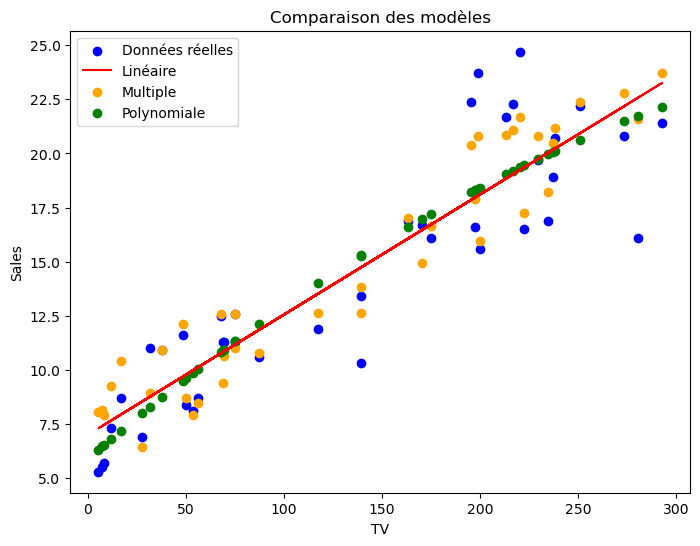

In [71]:
#  Visualisation des résultats des modèles
plt.figure(figsize=(8,6))
plt.scatter(X_test_s, y_test_s, color='blue', label='Données réelles')
plt.plot(X_test_s, y_pred_s_linear, color='red', label='Linéaire')
plt.scatter(X_test_s, y_pred_sk_multi, color='orange', label='Multiple')
plt.scatter(X_test_s, y_pred_poly, color='green', label='Polynomiale')
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("Comparaison des modèles")
plt.legend()
plt.show()